In [ ]:
koi!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# fetch dataset
chronic_kidney_disease = fetch_ucirepo(id=336)

# data (as pandas dataframes)
# x = chronic_kidney_disease.data.features
# y = chronic_kidney_disease.data.targets
# df=pd.DataFrame(x)
# df1=df.copy()
# print(df.head(3))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report


x = chronic_kidney_disease.data.features
y = chronic_kidney_disease.data.targets
df=pd.DataFrame(x)
df.head()



,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,15.4,44.0,7800.0,5.2,yes,yes,no,good,no,no
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,11.3,38.0,6000.0,NaN,no,no,no,good,no,no
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,9.6,31.0,7500.0,NaN,no,yes,no,poor,no,yes
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,11.2,32.0,6700.0,3.9,yes,no,no,poor,yes,yes
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,11.6,35.0,7300.0,4.6,no,no,no,good,no,no


In [ ]:
print(df.columns)
print(df.shape)

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane'],
      dtype='object')
(400, 24)


In [ ]:
print(y)

      class
0       ckd
1       ckd
2       ckd
3       ckd
4       ckd
..      ...
395  notckd
396  notckd
397  notckd
398  notckd
399  notckd

[400 rows x 1 columns]


In [ ]:
df.isnull().sum()

,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4
bgr,44


In [ ]:
print(df.describe())
""" To check what should we do with Nan values,the values are close to the means therefor we
fill the Nan values in all the columns with there respective mean values"""

              age          bp          sg          al          su         bgr  \
count  391.000000  388.000000  353.000000  354.000000  351.000000  356.000000   
mean    51.483376   76.469072    1.017408    1.016949    0.450142  148.036517   
std     17.169714   13.683637    0.005717    1.352679    1.099191   79.281714   
min      2.000000   50.000000    1.005000    0.000000    0.000000   22.000000   
25%     42.000000   70.000000    1.010000    0.000000    0.000000   99.000000   
50%     55.000000   80.000000    1.020000    0.000000    0.000000  121.000000   
75%     64.500000   80.000000    1.020000    2.000000    0.000000  163.000000   
max     90.000000  180.000000    1.025000    5.000000    5.000000  490.000000   

               bu          sc         sod         pot        hemo         pcv  \
count  381.000000  383.000000  313.000000  312.000000  348.000000  329.000000   
mean    57.425722    3.072454  137.528754    4.627244   12.526437   38.884498   
std     50.503006    5.7411

' To check what should we do with Nan values,the values are close to the means therefor we \nfill the Nan values in all the columns with there respective mean values'

In [ ]:
#filling Nan values
for c in df.columns:
    if df[c].dtype in [np.float64, np.int64]:
        df[c].fillna(df[c].median(), inplace=True)
    else:
        df[c].fillna(df[c].mode()[0], inplace=True)

print(df.isnull().sum())

age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
dtype: int64


/tmp/ipython-input-1177670130.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].median(), inplace=True)


In [ ]:
#categorical value to numerical
cat_cols = []
for c in df.columns:
    if df[c].dtype == object:
        cat_cols.append(c)

print("Categorical columns:", cat_cols)

#LabelEncoder to convert categorical column to numerical
le = LabelEncoder()
for c in cat_cols:
    df[c] = le.fit_transform(df[c])

df.head()

Categorical columns: []


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,15.4,44.0,7800.0,5.2,1,2,0,0,0,0
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,11.3,38.0,6000.0,4.8,0,1,0,0,0,0
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,9.6,31.0,7500.0,4.8,0,2,0,1,0,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,11.2,32.0,6700.0,3.9,1,1,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,11.6,35.0,7300.0,4.6,0,1,0,0,0,0


In [ ]:
print("Target value counts:\n", y.value_counts())

Target value counts:
 class 
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


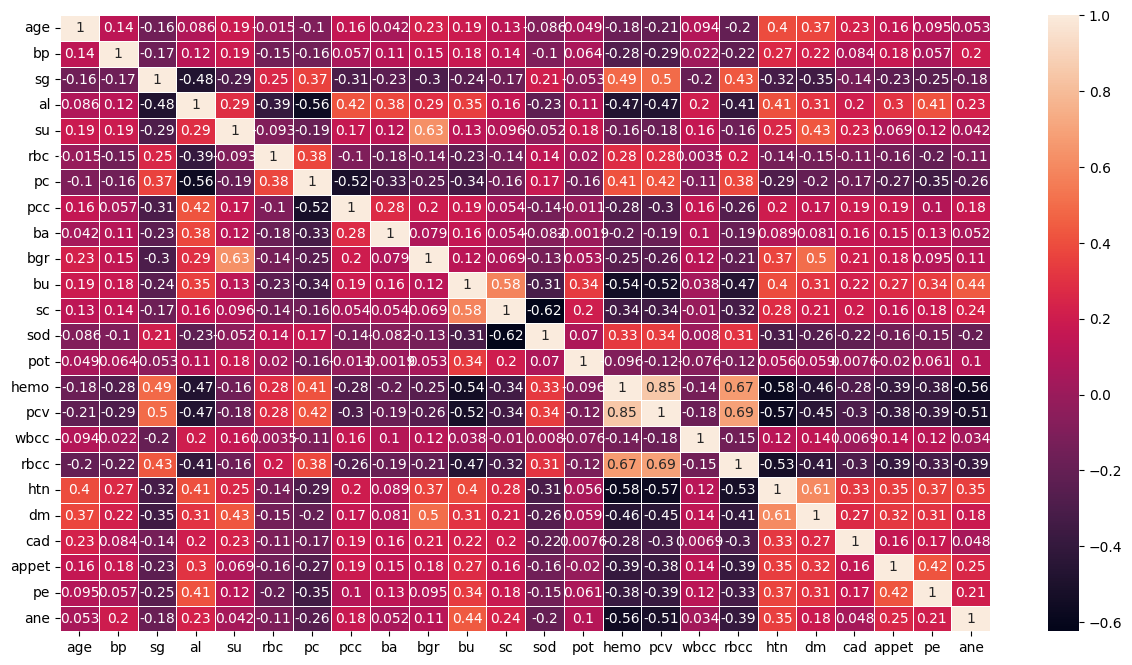

In [ ]:
plt.figure(figsize = (15, 8))
sns.heatmap(df.corr(), annot = True, linewidths = 0.5)
plt.show()

#for dimensity reduction we see we dont have any highly correlated column

In [ ]:
df01=df.copy()


In [ ]:
y.value_counts()


,count
class,
ckd,248
notckd,150
ckd\t,2


In [ ]:
y.shape

(400, 1)

In [ ]:
y['class'].unique()
print(y[y['class']=="ckd\t"])
y.drop(y[y['class']=="ckd\t"].index,inplace=True)
y.head()
print(y.value_counts())
print(y.shape)

Empty DataFrame
Columns: [class]
Index: []
class 
ckd       248
notckd    150
Name: count, dtype: int64
(398, 1)


/tmp/ipython-input-2380029773.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.drop(y[y['class']=="ckd\t"].index,inplace=True)


In [ ]:
df02=df01.copy()
df3=df01.copy()
print(df3.shape)

(400, 24)


In [ ]:
rowstodrop=[37,230]
df3.drop(df3.index[rowstodrop],inplace=True)
print(df3.shape)

(398, 24)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df3, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(318, 24) (318, 1)
(80, 24) (80, 1)


In [ ]:
clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)
clf.fit(X_train, y_train)

# -----------------------------
# 4. Predictions & Evaluation
# -----------------------------
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("\n=== Evaluation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#support tells us how many instances of each class is present in sample
#macro avg : irrespective of class size computes avg of each of their precision eg: (0.94+1)/2=0.97
#weighted: takes on average by taking equal quantity or instances of both class.




=== Evaluation Metrics ===
Accuracy:  0.9625
Precision: 0.9646
Recall:    0.9625

Classification Report:
               precision    recall  f1-score   support

         ckd       0.94      1.00      0.97        50
      notckd       1.00      0.90      0.95        30

    accuracy                           0.96        80
   macro avg       0.97      0.95      0.96        80
weighted avg       0.96      0.96      0.96        80



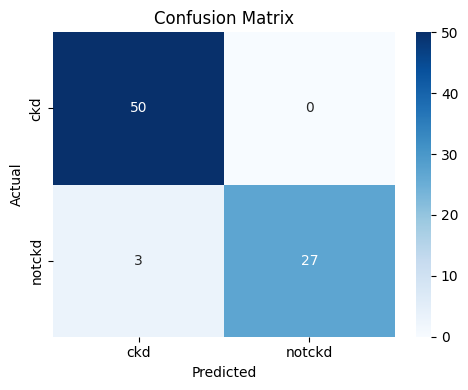

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

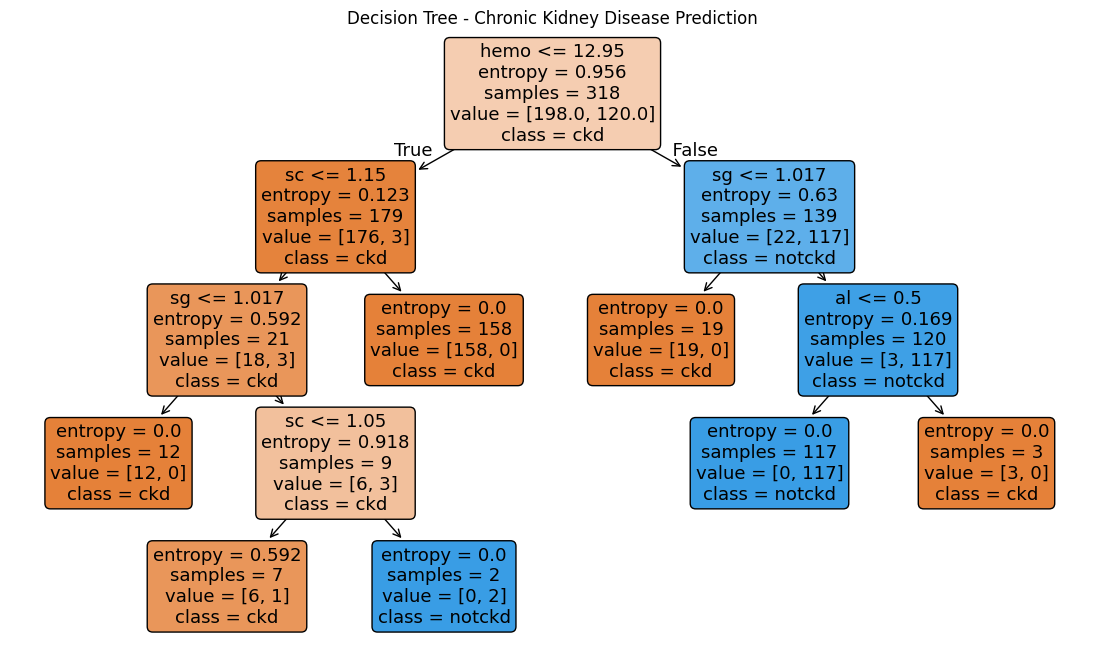

In [ ]:
# (c) Visualize Decision Tree
plt.figure(figsize=(14,8))
plot_tree(clf, filled=True, feature_names=df01.columns,
          class_names=[str(c) for c in np.unique(y)], rounded=True)
plt.title("Decision Tree - Chronic Kidney Disease Prediction")
plt.show()